 <h1><font style="color:blue">Project 2: Kaggle Competition - Inference</font> </h1>


In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:98% !important; }</style>"))
%load_ext autoreload  
%autoreload 2
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [33]:
import os
import tomllib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
import gc
for p in ['../..']:
    if p not in sys.path:
        # print(f"insert {p}")
        sys.path.insert(0, p)
print(sys.path)


['../..', '/home/kbardool/miniconda3/envs/opencv/lib/python312.zip', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12/lib-dynload', '', '/home/kbardool/miniconda3/envs/opencv/lib/python3.12/site-packages', '/tmp/tmpfmzwkwsn']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms.functional as TVF
# import torch.utils.data as data
# import torch.optim.lr_scheduler as lr_scheduler
# from torchvision import transforms
# from torch.utils.data import Dataset, DataLoader
import lightning as L
 
from torchinfo import summary

from torch.utils.tensorboard import SummaryWriter

# Use torchmetrics API to track and compute metrics automatically
# from torchmetrics import MeanMetric    # Aggregate a stream of value into their mean value.
# from torchmetrics.classification import MulticlassAccuracy # Compute Accuracy for multiclass tasks.
# from torch.utils.tensorboard import SummaryWriter

pd.set_option('display.width',180)
torch.set_printoptions(linewidth=180)
np.set_printoptions(linewidth=180)

In [5]:
# from training_code import *
# from models_code import  PretrainedResNet34, PretrainedResNet101
from dataloader_code import KenyanFoodDataModule
from models_code import  PretrainedResNet50, pretrained_resnet50 
from training_code import denormalize, display_images, load_checkpoint
from training_code import SystemConfiguration, InferenceConfiguration


In [6]:
# NOTEBOOK_NAME = os.path.basename(os.environ.get('JPY_SESSION_NAME'))
NOTEBOOK_NAME = "Copy1_inference.ipynb"
print(f"Notebook name : {NOTEBOOK_NAME}")
os.environ["WANDB_NOTEBOOK_NAME"] = NOTEBOOK_NAME


Notebook name : Copy1_inference.ipynb


<h1> <font style="color:green"> Helper Code </font></h1>

In [7]:
def delete_vars(variables = ['model',  'metrics', 'train_config', 'sys_config', 'optimizer', 'scheduler', 'train_loader', 'val_loader', 'data_module']):
    for vr in variables:
        global_vars = globals()
        if vr in global_vars:
            try:
                del globals()[vr]
                print(f" {vr:15s} deleted . . . ")
            except Exception as e:
                print(e)
        else:
            print(f" {vr:15s} NOT defined . . .")
    
    print(f" gc.collect() : {gc.collect()}")
    print(f" Cuda empty cache : {torch.cuda.empty_cache()}")


## Test Dataset and Data Module

In [ ]:
delete_vars()
gc.collect()

In [ ]:
# data loader
data_module = KenyanFoodDataModule(
    data_root = './images', 
    batch_size = 12,
    num_workers = 2,
    image_shape = 224,
    class_boost =  np.array([1., 1., 1., 1., 3., 1., 1., 1., 1., 1., 1., 1., 1.]),
    augmentation = 'V5',
    pin_memory=True,
    seed=84
)
data_module.prepare_data()
data_module.setup()
# train_loader = data_module.train_dataloader()
# val_loader = data_module.val_dataloader()

In [ ]:
len(data_module.train_dataset.data_dict)
iter_trn_loader = iter(data_module.train_dataloader())

# len(data_module.val_dataset.data_dict)
# iter_val_loader = iter(data_module.val_dataloader())

# len(data_module.test_dataset.data_dict)
# iter_tst_loader = iter(data_module.test_dataloader())
# data_module.label_to_name

In [ ]:
# display_class_images(denormed_images, labels, names, filter= 9)
# display_class_images(denormed_images, labels, names, filter= 4)

In [ ]:
images, labels = next(iter_trn_loader)
names = [data_module.label_to_name[x] for x in labels.numpy()]
print("labels: ", labels)
print("names : ", names)
denormed_images = denormalize(images)

display_images(denormed_images, labels, names)
# display_images(images, labels, names)

In [ ]:
images, labels = next(iter_trn_loader)
names = [data_module.label_to_name[x] for x in labels.numpy()]
print("labels: ", labels)
print("names : ", names)
denormed_images = denormalize(images)

display_images(denormed_images, labels, names)
# display_images(images, labels, names)

### Validation Dataset

In [ ]:
len(data_module.val_dataset.data_dict)
iter_val_loader = iter(data_module.val_dataloader())

In [ ]:
images, labels = next(iter_val_loader)
denormed_images = denormalize(images)
names = [data_module.label_to_name[x] for x in labels.numpy()]
print("labels: ", labels)
print("names : ", names)

display_images(denormed_images, labels, names)
display_images(images, labels, names)

In [ ]:
images, labels = next(iter_val_loader)
denormed_images = denormalize(images)
names = [data_module.label_to_name[x] for x in labels.numpy()]
print("labels: ", labels)
print("names : ", names)


display_images(denormed_images, labels, names)
display_images(images, labels, names)

# <font style="color:green">Prediction</font>

In [128]:
delete_vars()
gc.collect()

 model           deleted . . . 
 metrics         NOT defined . . .
 train_config    NOT defined . . .
 sys_config      deleted . . . 
 optimizer       NOT defined . . .
 scheduler       NOT defined . . .
 train_loader    deleted . . . 
 val_loader      deleted . . . 
 data_module     deleted . . . 
 gc.collect() : 17962
 Cuda empty cache : None


34905

In [129]:
from pathlib import Path
import glob

# import subprocess
# wandb_run_id = 're1afc8i'
wandb_run_id = 'agklpjn2'
files = [p.name for p in Path("./models").glob(f"*{wandb_run_id}*")]
# list_cmd = f"ls -l ./models/*{wandb_run_id}*"
# output = subprocess.run(list_cmd, shell=True, stdout=True, text = True, check=True)
# output = subprocess.run([f"ls ./models/*{wandb_run_id}*", "-"],  shell=True, stdout=True, text = True, check=True)
files
files.sort()
files

['resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_bestloss.pt',
 'resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_bestacc.pt',
 'resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_aug_V5_wd8.5e-03_final_ep149_agklpjn2.pt']

['resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_aug_V5_wd8.5e-03_final_ep149_agklpjn2.pt',
 'resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_bestacc.pt',
 'resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_bestloss.pt']

In [102]:
files

[]

In [ ]:
sys_config = SystemConfiguration()
infer_config = InferenceConfiguration()

infer_config.batch_size = 18
infer_config.session_name = NOTEBOOK_NAME
infer_config.model_name = 'resnet50'
infer_config.inference_folder = "./inference_outputs"
infer_config.run_name = wandb_run_id
infer_config.image_shape = 224
infer_config.num_workers = 1

# infer_config.model_file_name = "resnet50_BS_128_LR_1.0e-02_fc43_wd8.5e-03_wp_00_hnowwm87_aug_V5_wd8.5e-03_final_ep219_hnowwm87.pt"
# infer_config.model_file_name = "resnet50_BS_096_LR_1.0e-02_fc43_wd7.5e-03_wp_00_re1afc8i_bestacc.pt"
# infer_config.model_file_name = "resnet50_BS_096_LR_1.0e-02_fc43_wd7.5e-03_wp_00_re1afc8i_aug_V5_wd7.5e-03_final_ep149_re1afc8i.pt"

suffix = "final"
infer_config.model_file_name = files[0]

# suffix = "bestacc"
# infer_config.model_file_name = files[1]
# suffix = "bestloss"
# infer_config.model_file_name = files[2]

assert suffix in infer_config.model_file_name, f"Model file name : {infer_config.model_file_name} does not contain suffix : {suffix}"

print(" Inference Configuration : ")
for k,v in infer_config.__dict__.items():
    print(f"  {k:25s}: {v}")

 Inference Configuration : 
  batch_size               : 18
  data_root                : ./images
  device                   : cuda
  epochs_count             : 20
  image_shape              : 224
  initialization           : None
  logs_root                : ./logs
  model_name               : resnet50
  notebook_name            : 
  num_workers              : 1
  project_name             : 
  run_name                 : agklpjn2
  session_name             : Copy1_inference.ipynb
  test_interval            : 1
  inference_folder         : ./inference_outputs
  model_file_name          : resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_aug_V5_wd8.5e-03_final_ep149_agklpjn2.pt


In [152]:
#----------------------------------------------------
# Data Loader
#----------------------------------------------------
data_module = KenyanFoodDataModule(
    data_root = infer_config.data_root, 
    batch_size = infer_config.batch_size, 
    num_workers = infer_config.num_workers, 
    image_shape = infer_config.image_shape,
    # augmentation = infer_config.augmentation,
    pin_memory=True,
    seed=84
)
data_module.prepare_data()
data_module.setup()
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()
test_loader = data_module.test_dataloader()
print()
# print(f" Number of samples in train set: {len(train_loader.dataset)}")
# print(f" Number of samples in val set  : {len(val_loader.dataset)}")
print(f" Number of samples in test set : {len(test_loader.dataset)}")


 DataModule Initialization Started
 name_to_label: {'bhaji': 0, 'chapati': 1, 'githeri': 2, 'kachumbari': 3, 'kukuchoma': 4, 'mandazi': 5, 'masalachips': 6, 'matoke': 7, 'mukimo': 8, 'nyamachoma': 9, 'pilau': 10, 'sukumawiki': 11, 'ugali': 12}
 label to name: {0: 'bhaji', 1: 'chapati', 2: 'githeri', 3: 'kachumbari', 4: 'kukuchoma', 5: 'mandazi', 6: 'masalachips', 7: 'matoke', 8: 'mukimo', 9: 'nyamachoma', 10: 'pilau', 11: 'sukumawiki', 12: 'ugali'}
 image shape  : (224, 224)
 batch_size   : 18
 class boost  : tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
 num_workers  : 1
 seed         : 84
 augmentation : None
 training augmentations: 
 Compose(
    Resize(size=[256, 256], interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
 DataModule Initialization Completed
 DataModule Setup started - stage None
    class counts: {0: 537, 1: 733, 2: 407, 3: 420, 4:

In [147]:
checkpoint = load_checkpoint('models', infer_config.model_file_name)
checkpoint.keys()

models/resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_aug_V5_wd8.5e-03_final_ep149_agklpjn2.pt
 loading checkpoint from models/resnet50_BS_096_LR_1.0e-02_fc43_wd8.5e-03_wp_00_agklpjn2_aug_V5_wd8.5e-03_final_ep149_agklpjn2.pt


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'metrics', 'training_config'])

In [149]:
# for i in checkpoint['optimizer_state_dict']['state'].keys():
#     for j in checkpoint['optimizer_state_dict']['state'][i].keys():
#         print(f" {i} - {j} : {checkpoint['optimizer_state_dict']['state'][i][j].shape}")

print(f" last epoch :  {checkpoint['epoch']}")

print("\n model state dict: ")
print(" -------------------------")
for k,v in checkpoint['model_state_dict'].items():
    if isinstance(v, np.ndarray) or isinstance(v, torch.Tensor):
        print(f"  {k:25s}: {v.shape}")
    else:
        print(f"  {k:25s}: {v}")

for i in range(len(checkpoint['optimizer_state_dict']['param_groups'])):
    print(f"\n optimizer Param group {i}: ")
    print(" -------------------------")
    for k,v in checkpoint['optimizer_state_dict']['param_groups'][i].items():
        if isinstance(v, np.ndarray) or isinstance(v, torch.Tensor):
            print(f"  {k:25s}: {v.shape}")
        else:
            print(f"  {k:25s}: {v}")
            
print("\n scheduler: ")
print(" -------------------")
for k,v in checkpoint['scheduler_state_dict'].items():
    print(f"  {k:25s}: {v}")
print("\n training config: ")
print(" -------------------")
for k,v in checkpoint['training_config'].__dict__.items():
    print(f"  {k:25s}: {v}")
print("\n Metrics: ")
print(" ----------")
for k,v in checkpoint['metrics'].__dict__.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:25s}: {v.shape}")
    else:
        print(f"  {k:25s}: {v}")


 last epoch :  149

 model state dict: 
 -------------------------
  resnet.conv1.weight      : torch.Size([64, 3, 7, 7])
  resnet.bn1.weight        : torch.Size([64])
  resnet.bn1.bias          : torch.Size([64])
  resnet.bn1.running_mean  : torch.Size([64])
  resnet.bn1.running_var   : torch.Size([64])
  resnet.bn1.num_batches_tracked: torch.Size([])
  resnet.layer1.0.conv1.weight: torch.Size([64, 64, 1, 1])
  resnet.layer1.0.bn1.weight: torch.Size([64])
  resnet.layer1.0.bn1.bias : torch.Size([64])
  resnet.layer1.0.bn1.running_mean: torch.Size([64])
  resnet.layer1.0.bn1.running_var: torch.Size([64])
  resnet.layer1.0.bn1.num_batches_tracked: torch.Size([])
  resnet.layer1.0.conv2.weight: torch.Size([64, 64, 3, 3])
  resnet.layer1.0.bn2.weight: torch.Size([64])
  resnet.layer1.0.bn2.bias : torch.Size([64])
  resnet.layer1.0.bn2.running_mean: torch.Size([64])
  resnet.layer1.0.bn2.running_var: torch.Size([64])
  resnet.layer1.0.bn2.num_batches_tracked: torch.Size([])
  resnet.layer1

In [150]:
# del model
model = PretrainedResNet50()

In [151]:
for wght in [model.resnet.bn1.bias,
             model.resnet.layer1[1].bn1.bias,
             model.resnet.layer1[2].bn1.bias, 
             model.resnet.layer2[1].bn1.bias, 
             model.resnet.layer3[1].bn1.bias, 
             model.resnet.layer4[1].bn1.bias, 
             model.resnet.fc.bias]:
    print(f" {wght.sum().numpy():15.7f}", end='')
    
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

for wght in [model.resnet.bn1.bias,
             model.resnet.layer1[1].bn1.bias,
             model.resnet.layer1[2].bn1.bias, 
             model.resnet.layer2[1].bn1.bias, 
             model.resnet.layer3[1].bn1.bias, 
             model.resnet.layer4[1].bn1.bias, 
             model.resnet.fc.bias]:
    print(f" {wght.sum().numpy():15.7f}", end='')

print()
print("Model on CUDA: ", next(model.parameters()).is_cuda)
_ = model.to(infer_config.device)
print("Model on CUDA: ", next(model.parameters()).is_cuda)
_ = model.eval()

     175.5481262     -21.1120377     -13.3138590     -63.3077507    -177.2554626    -524.6234131       0.0005400

<All keys matched successfully>

     175.5481262     -21.1120377     -13.3138590     -63.3077507     -37.4807777    -110.3607025       0.0099946
Model on CUDA:  False
Model on CUDA:  True


In [153]:
rows = []
TOTAL_BATCHES = len(test_loader) 
print(f" Total batches to process : {TOTAL_BATCHES:3.0f}")
for batch_id,(image, image_ids) in enumerate(test_loader):
    if (batch_id+1) % 10 == 0:
        print(f" Batch: {batch_id+1:3d} of {TOTAL_BATCHES} . . .")
    
    image = image.to(infer_config.device)
    with torch.no_grad():
        output = model(image)
        probabilities = F.softmax(output, dim=1)
        prob_max = probabilities.max(dim=1)
        class_names = list(map(lambda x: data_module.label_to_name[x.item()], prob_max.indices))
        # preds = output.argmax(dim=1, keepdim=True).flatten()        

    # for idx, (image_id, class_id, class_name, class_prob) in enumerate(zip(image_ids, prob_max.indices, class_names, prob_max.values)):
    #     print(f" Batch ID: {batch_id:3d},Image:{batch_id*infer_config.batch_size + idx:4d}  "
    #           f"ID: {image_id:24s} Pred: {class_id.item():2d} - {class_name:20s} prob:{class_prob.item():.4f}")

    rows.extend(list(zip(image_ids, class_names, prob_max.indices.tolist(), prob_max.values.tolist()))) 
    # if batch_id >= 10:
    #     break

print(f" Batch: {batch_id+1:3d} of {TOTAL_BATCHES} . . .")
df_output = pd.DataFrame(rows, columns=['id', 'class', 'class_id','prob']) ## .convert_dtypes(infer_objects=True)
    

 Total batches to process :  91
 Batch:  10 of 91 . . .
 Batch:  20 of 91 . . .
 Batch:  30 of 91 . . .
 Batch:  40 of 91 . . .
 Batch:  50 of 91 . . .
 Batch:  60 of 91 . . .
 Batch:  70 of 91 . . .
 Batch:  80 of 91 . . .
 Batch:  90 of 91 . . .
 Batch:  91 of 91 . . .


In [154]:
# df_output = pd.DataFrame(rows, columns=['id', 'class', 'class_id','prob']) ## .convert_dtypes(infer_objects=True)
df_output.info()
df_output.head(10)
df_output.tail(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1638 entries, 0 to 1637
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1638 non-null   object 
 1   class     1638 non-null   object 
 2   class_id  1638 non-null   int64  
 3   prob      1638 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 51.3+ KB


,id,class,class_id,prob
0,9156739011499789258,nyamachoma,9,0.765928
1,2049465964503133373,kachumbari,3,0.697562
2,6446998501027132988,nyamachoma,9,0.978675
3,4194396063119815321,ugali,12,0.999732
4,9018117998187006009,mandazi,5,0.778385
5,6246759883907852128,masalachips,6,0.999961
6,16478122708528316044,nyamachoma,9,0.996212
7,14045745760440690312,masalachips,6,0.263905
8,7872954221890963019,matoke,7,0.798686
9,4868486697531317477,chapati,1,0.999389


,id,class,class_id,prob
1628,7596268598227627643,ugali,12,0.995552
1629,1704933171119356655,nyamachoma,9,0.996043
1630,9262750812933300107,masalachips,6,0.876608
1631,4858510207088946382,nyamachoma,9,0.994920
1632,5807637199214953403,nyamachoma,9,0.745503
1633,18302448610371772604,githeri,2,0.999992
1634,15920672464676076400,chapati,1,0.994362
1635,3232020170382870007,bhaji,0,0.532651
1636,3094804487341098468,kachumbari,3,0.906010
1637,5827342261332058667,sukumawiki,11,0.526109


In [158]:
suffix = 'final'
print(f"wandb run name: {infer_config.run_name}")

print(f"suffix : {suffix}")

output_file_name = Path(infer_config.inference_folder)/f'infer_{infer_config.run_name}_{suffix}.csv'
submission_file_name = Path(infer_config.inference_folder)/f'infer_{infer_config.run_name}_{suffix}_submission.csv'
print(f" Output file name     : {output_file_name}")
print(f" Submission file name : {submission_file_name}")


wandb run name: agklpjn2
suffix : final
 Output file name     : inference_outputs/infer_agklpjn2_final.csv
 Submission file name : inference_outputs/infer_agklpjn2_final_submission.csv


In [159]:
df_output.to_csv(output_file_name, index=False)
df_output.to_csv(submission_file_name, index=False, columns=['id', 'class'])

In [ ]:
## kaggle competitions submit -c open-cv-py-torch-project-2-classification-round-4 -f submission.csv  -m "Message"

In [120]:
df_output.groupby('class').count()  

,id,class_id,prob
class,,,
bhaji,165,165,165
chapati,253,253,253
githeri,124,124,124
kachumbari,104,104,104
kukuchoma,20,20,20
mandazi,166,166,166
masalachips,117,117,117
matoke,92,92,92
mukimo,48,48,48


In [79]:
def box_plot(df_output, title="Class Probabilities"):
    f, ax = plt.subplots(figsize=(10, 5))

    _ = sns.boxplot(
        df_output, x="prob", y="class", hue="class_id",
        whis=[0, 100], width=.6, palette="vlag"
    )

    # Add in points to show each observation
    _ = sns.stripplot(df_output, x="prob", y="class", size=2, color=".3")

    # Tweak the visual presentation
    _ = ax.legend(loc='lower left', bbox_to_anchor=(1, 0.5), ncol=1)   
    _ = ax.xaxis.grid(True)
    _ = ax.set(ylabel="")
    _ = ax.set_title(title)
    sns.despine(trim=True, left=True)

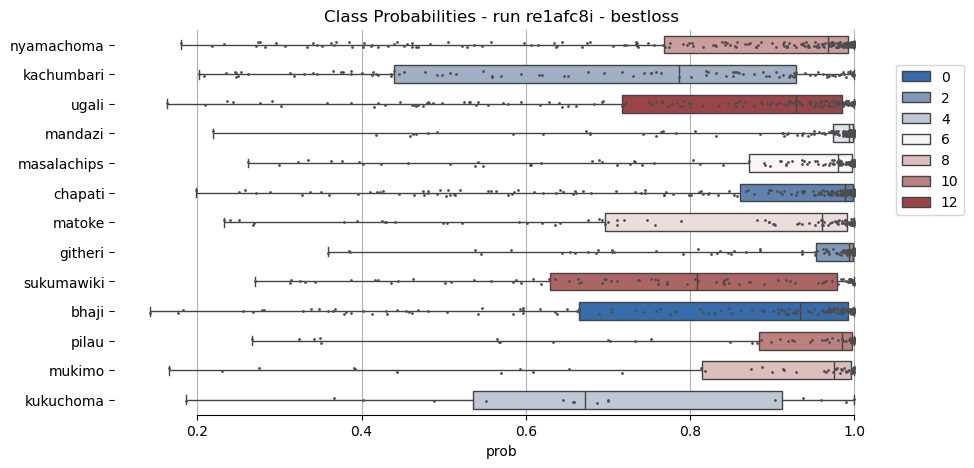

In [80]:
 box_plot(df_output, f"Class Probabilities - run {wandb_run_id} - {suffix}")

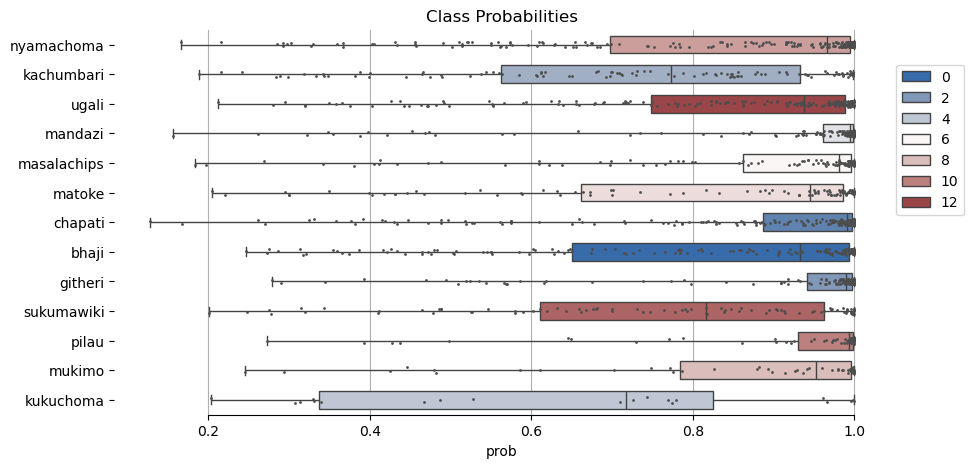

In [121]:
box_plot(df_output)

In [38]:
input_df = pd.read_csv(f'my_inference_1_{wandb_run_id}_submission.csv')
input_df.head()
input_df.tail(10)

,id,class
0,9156739011499789258,nyamachoma
1,2049465964503133373,kachumbari
2,6446998501027132988,nyamachoma
3,4194396063119815321,ugali
4,9018117998187006009,mandazi


,id,class
1628,7596268598227627643,ugali
1629,1704933171119356655,nyamachoma
1630,9262750812933300107,masalachips
1631,4858510207088946382,nyamachoma
1632,5807637199214953403,nyamachoma
1633,18302448610371772604,githeri
1634,15920672464676076400,chapati
1635,3232020170382870007,bhaji
1636,3094804487341098468,kachumbari
1637,5827342261332058667,ugali


In [39]:
input_df = pd.read_csv(f'my_inference_1_{wandb_run_id}.csv')
input_df.head()
input_df.tail(10)

,id,class,class_id,prob
0,9156739011499789258,nyamachoma,9,0.834779
1,2049465964503133373,kachumbari,3,0.617575
2,6446998501027132988,nyamachoma,9,0.838621
3,4194396063119815321,ugali,12,0.999020
4,9018117998187006009,mandazi,5,0.542964


,id,class,class_id,prob
1628,7596268598227627643,ugali,12,0.994358
1629,1704933171119356655,nyamachoma,9,0.994839
1630,9262750812933300107,masalachips,6,0.956508
1631,4858510207088946382,nyamachoma,9,0.993514
1632,5807637199214953403,nyamachoma,9,0.822196
1633,18302448610371772604,githeri,2,0.999924
1634,15920672464676076400,chapati,1,0.994831
1635,3232020170382870007,bhaji,0,0.802815
1636,3094804487341098468,kachumbari,3,0.975563
1637,5827342261332058667,ugali,12,0.584272
